In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


x_train: (3000, 784)
y_train: (3000, 10)


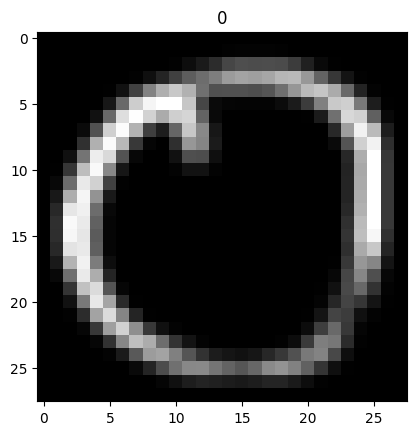

In [4]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt
from PIL import Image

train_dir = "/content/drive/MyDrive/ai & ml/workshop4/Copy of devnagari digit/DevanagariHandwrittenDigitDataset/Test"
test_dir = "/content/drive/MyDrive/ai & ml/workshop4/Copy of devnagari digit/DevanagariHandwrittenDigitDataset/Train"

img_height, img_width = 28, 28

def load_images_from_folder(folder):
    images = []
    labels = []

    class_names = sorted(os.listdir(folder))
    class_map = {name: i for i, name in enumerate(class_names)}

    for class_name in class_names:
        class_path = os.path.join(folder, class_name)

        if not os.path.isdir(class_path):
            continue

        label = class_map[class_name]

        for filename in os.listdir(class_path):
            img_path = os.path.join(class_path, filename)

            try:
                img = Image.open(img_path).convert("L")
                img = img.resize((img_width, img_height))
                img = np.array(img) / 255.0

                images.append(img)
                labels.append(label)
            except:
                continue

    return np.array(images), np.array(labels)

x_train, y_train = load_images_from_folder(train_dir)
x_test, y_test = load_images_from_folder(test_dir)

x_train = x_train.reshape(-1, 784)
x_test = x_test.reshape(-1, 784)

y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

print("x_train:", x_train.shape)
print("y_train:", y_train.shape)

plt.imshow(x_train[0].reshape(28, 28), cmap='gray')
plt.title(np.argmax(y_train[0]))
plt.show()

In [5]:

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(784,)),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 235,146 (918.54 KB)

 Trainable params: 235,146 (918.54 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
history = model.fit(
    x_train,
    y_train,
    batch_size=128,
    epochs=20,
    validation_split=0.15
)

Epoch 1/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.6957 - loss: 1.0748 - val_accuracy: 0.2889 - val_loss: 7.5470
Epoch 2/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9102 - loss: 0.2960 - val_accuracy: 0.3022 - val_loss: 10.2484
Epoch 3/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9498 - loss: 0.1796 - val_accuracy: 0.2844 - val_loss: 10.1498
Epoch 4/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9675 - loss: 0.1280 - val_accuracy: 0.2933 - val_loss: 10.0103
Epoch 5/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9800 - loss: 0.0901 - val_accuracy: 0.2933 - val_loss: 10.3548
Epoch 6/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9851 - loss: 0.0698 - val_accuracy: 0.3067 - val_loss: 10.4558
Epoch 7/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9933 - loss: 0.0453 - val_accuracy: 0.3044 - val_loss: 10.8684
Epoch 8/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9973 - loss: 0.0343 - val_accuracy: 0.30

In [7]:
test_loss, test_acc = model.evaluate(x_test, y_test)
print("Test accuracy:", test_acc)

39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9870 - loss: 0.0516
Test accuracy: 0.987002432346344


In [8]:
model.save("/content/drive/MyDrive/ai & ml/workshop4/model.keras")

In [9]:
from tensorflow.keras.models import load_model

loaded_model = load_model("/content/drive/MyDrive/ai & ml/workshop4/model.keras")
print("Model loaded successfully")

Model loaded successfully


In [10]:
pred_probs = model.predict(x_test)

pred_labels = np.argmax(pred_probs, axis=1)

true_labels = np.argmax(y_test, axis=1)

for i in range(10):
    print(f"Predicted: {pred_labels[i]}, Actual: {true_labels[i]}")

39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
Predicted: 0, Actual: 0
Predicted: 0, Actual: 0
Predicted: 0, Actual: 0
Predicted: 0, Actual: 0
Predicted: 0, Actual: 0
Predicted: 0, Actual: 0
Predicted: 0, Actual: 0
Predicted: 0, Actual: 0
Predicted: 0, Actual: 0
Predicted: 0, Actual: 0
